# E2 - Loading and visualizing data from flat files (using AI)

### Part 1 - Flat data and headers

In [18]:
import pandas as pd

# Defining headers
my_headers = ['Date', 'Time', 'Depth', 'Temperature', 'Salinity']

# Reading ASCII file
df = pd.read_csv('for_nitpicker.dat', sep='\s+', names=my_headers)

# Saving file as CSV
df.to_csv('Nitpickers_CTD-data_Novemver_2008.csv', index=False)

# Display 
df.head()

,Date,Time,Depth,Temperature,Salinity
0,11/29/2008,06:52,5,28.97,35.21
1,11/29/2008,06:52,6,28.98,35.21
2,11/29/2008,06:52,7,28.99,35.21
3,11/29/2008,06:52,8,28.96,35.21
4,11/29/2008,06:52,9,28.99,35.21


### Part 2 - profiles

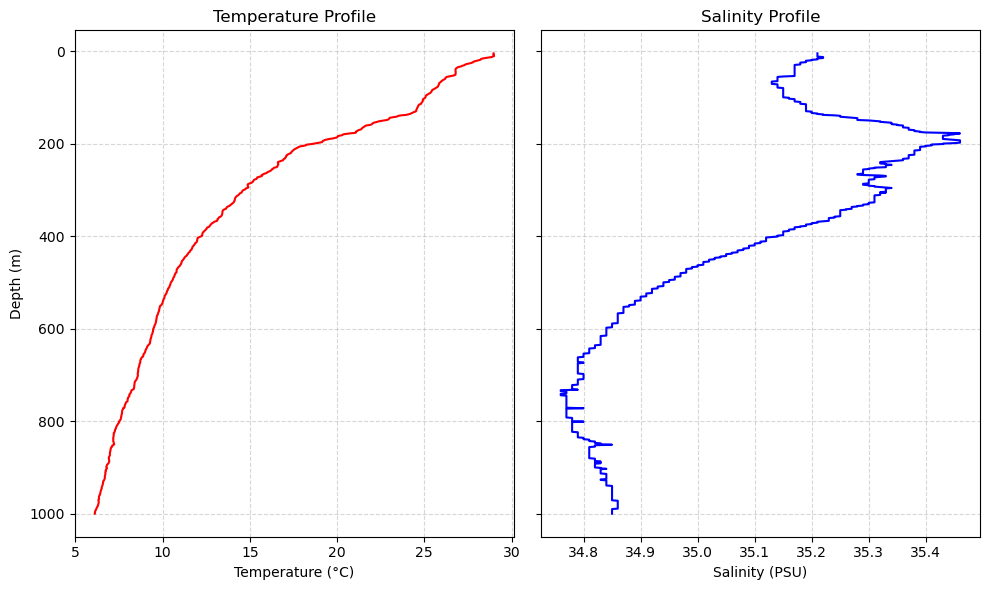

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading CSV file
df = pd.read_csv('Nitpickers_CTD-data_Novemver_2008.csv')

# Creating a figure with two side-by-side subplots sharing the Y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10, 6))

# Plotting Temperature in the first panel
ax1.plot(df['Temperature'], df['Depth'], color='red', linestyle='-')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Depth (m)')
ax1.set_title('Temperature Profile')
ax1.grid(True, linestyle='--', alpha=0.5)

# Plotting Salinity in the second panel
ax2.plot(df['Salinity'], df['Depth'], color='blue', linestyle='-')
ax2.set_xlabel('Salinity (PSU)')
ax2.set_title('Salinity Profile')
ax2.grid(True, linestyle='--', alpha=0.5)

# Inverting the Y-axis (so depth 0 is at the top)
ax1.invert_yaxis()

# Display
plt.tight_layout()
plt.show()

### Part 3 - time series

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file, recognizing 'NULL' as missing values
df = pd.read_csv('SAA2_WC_2017_metocean_10min_avg.csv', na_values='NULL')

# Convert TIME_SERVER to datetime and set it as the index
df['TIME_SERVER'] = pd.to_datetime(df['TIME_SERVER'])
df.set_index('TIME_SERVER', inplace=True)

# Select data from departure to July 4th (inclusive)
subset = df[:'2017-07-04'].copy()

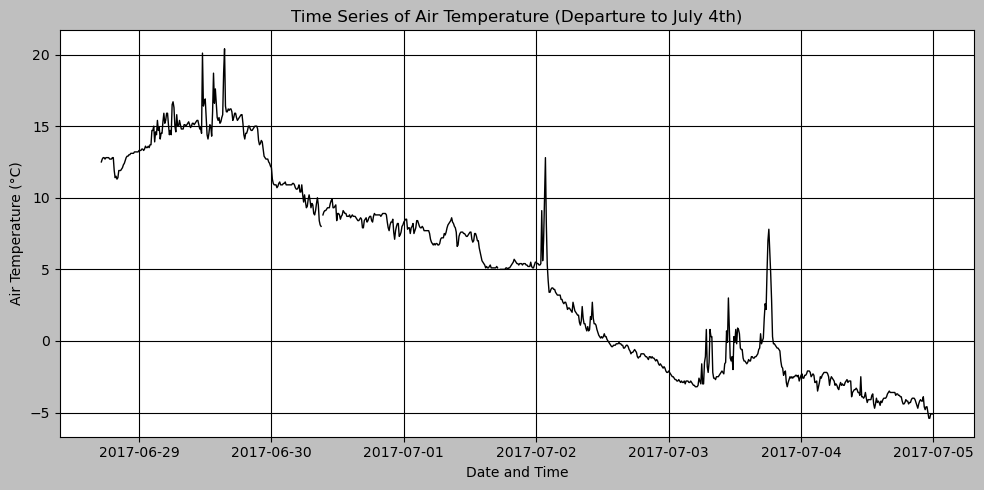

In [21]:
# 2. Time series of Temperature (Grayscale style)
plt.style.use('grayscale')
plt.figure(figsize=(10, 5))
plt.plot(subset.index, subset['AIR_TEMPERATURE'], linewidth=1)
plt.xlabel('Date and Time')
plt.ylabel('Air Temperature (°C)')
plt.title('Time Series of Air Temperature (Departure to July 4th)')
plt.grid(True)
plt.tight_layout()
plt.savefig('temp_timeseries.png')
plt.show()

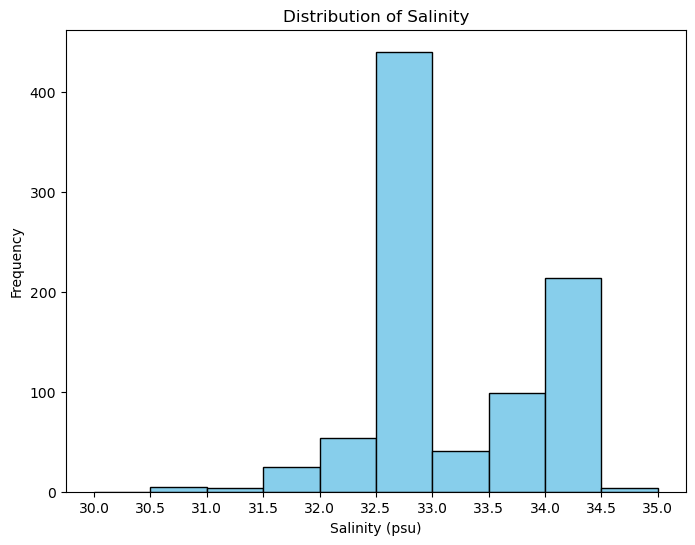

In [22]:
# 3. Histogram of Salinity (Bins of 0.5 psu between 30 and 35)
plt.style.use('default') # Reset style for histogram
plt.figure(figsize=(8, 6))
bins = np.arange(30, 35.5, 0.5)
plt.hist(subset['TSG_SALINITY'].dropna(), bins=bins, edgecolor='black', color='skyblue')
plt.xlabel('Salinity (psu)')
plt.ylabel('Frequency')
plt.title('Distribution of Salinity')
plt.xticks(bins)
plt.savefig('salinity_hist.png')
plt.show()

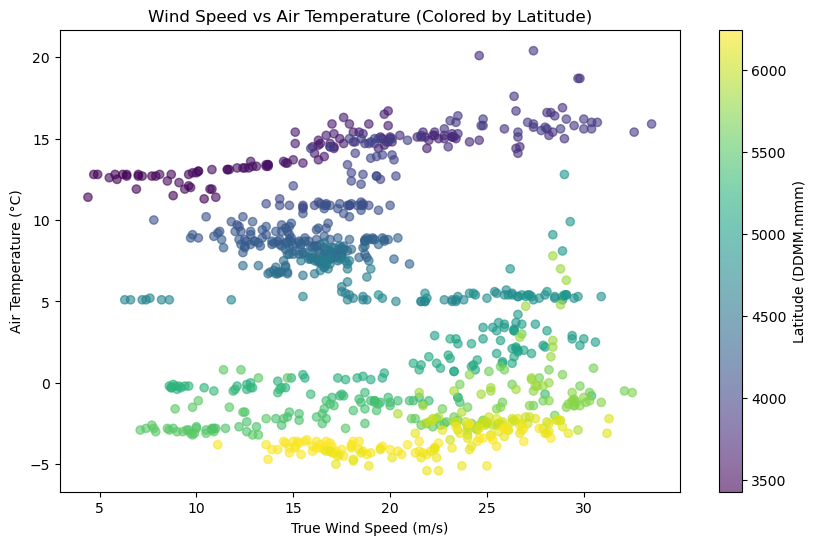

In [23]:
# 5. Scatter Plot: Wind Speed vs Air Temperature (Color by Latitude)
plt.figure(figsize=(10, 6))
sc = plt.scatter(subset['WIND_SPEED_TRUE'], subset['AIR_TEMPERATURE'], 
                 c=subset['LATITUDE'], cmap='viridis', alpha=0.6)
plt.colorbar(sc, label='Latitude (DDMM.mmm)')
plt.xlabel('True Wind Speed (m/s)')
plt.ylabel('Air Temperature (°C)')
plt.title('Wind Speed vs Air Temperature (Colored by Latitude)')
plt.savefig('wind_temp_scatter.png', dpi=300)
plt.show()